In [1]:
#Imports
import sys,os
#os.environ['MKL_NUM_THREADS'] = '4' # set number of MKL threads to run in parallel
from quspin.operators import hamiltonian,quantum_operator
from quspin.basis import spin_basis_1d
from numpy.random import uniform,seed
from joblib import delayed,Parallel
from itertools import combinations
from functools import partial
import numpy as np
import gc
import pickle
from time import time
from quspin.tools.measurements import diag_ensemble
from quspin.tools.evolution import ED_state_vs_time
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, show, figure, xlabel, ylabel, xscale, yscale, legend, loglog, imshow, scatter
from numpy import pi, exp, log, sin , cos, tan, log, array
import quspin


In [2]:
def mod_fin_string(string,s): #string = eg "10" to project an up and down s = operator
    ns = len(string)
    #Max string length
    if ns>L: # String must be equal to or less than length of chain
        return "ERROR"
    else:
        pass
    
    def signs(string: str) -> list:
        """Calculates parity of sites through the construction
        (1+X)(1-X)(1+X)...
        """
        signs = []
        for digit in string:
            if digit=="1":
                signs.append(1)
            else:
                signs.append(-1)
        return signs
    def term_parity(signs :list,indexes:tuple,start:int)->int:
        parity = 1
        for i in indexes:
            parity*= signs[(i-start)%len(signs)]
        return parity

    def mod_linears(start:int,m:int,signs:list):
        #Find all indices in string
        ind=[i%L for i in range(start,start+ns)]
        #All combinations
        perm=list(combinations(ind,m))
        #Add each coupling to operator
        for j in range(len(perm)):
            #The magnitude of each term is the same, parity is determined by term_parity()
            parity = term_parity(signs,perm[j],start)
            S_temp=[parity*1/(L*(2**ns))] 
            for i in range(len(perm[j])):
                S_temp.append(perm[j][i])
        ##Saving Couplings lists
            if j==0: 
                #Initialize
                S_temp_2=[S_temp]
            else: 
                #Append
                S_temp_2.append(S_temp)
        return S_temp_2
    sign_list = signs(string)
        
    #List to store orders of interaction
    o_type=np.empty(ns,dtype=object)
    
    for i in range(ns):
        #ex: "z"*2= "zz"
        o_type[i]=s*(i+1)

    #Iterate over each Site
    for k in range(L):
        #Iterate over different string lengths
      for i in range(ns):
          #First item defines list
          if k==0 and i==0:
              #example: i = 0 operator_list = [['x', linears(k,1)]]
              operator_list=[[o_type[i],mod_linears(k,i+1,sign_list)]]
          else:
              operator_list.append([o_type[i],mod_linears(k,i+1,sign_list)])
    S_temp_1 = [[(1/((ns*2**ns))), i] for i in range(ns)]
    #S_temp_1 = [[(1/((ns*2**(ns)))), 1] ]
    operator_list.append(["I",S_temp_1])
    operator_dict=dict(S=operator_list)
    O = quantum_operator(operator_dict,basis=basis,check_symm=False,check_herm=False)
    return O, operator_list
    

In [3]:
def state(config:str,basis:quspin.basis)->np.ndarray:
    num= int(config, 2)
    idx= basis.index(num)
    psi_red = np.zeros(basis.Ns); psi_red[idx]=1
    psi_full = basis.project_from(psi_red, sparse=False)
    return psi_full

def state_x(config_x: str, basis) -> np.ndarray:
    """
    config_x: string like '+-++-' or '0101' (define 1/+ = +x, 0/- = -x)
    basis: QuSpin z-basis
    returns full Hilbert-space state vector in z-basis
    """
    L = basis.L
    assert len(config_x) == L

    # map symbols to s_i = ±1
    s = np.empty(L, dtype=int)
    for i,c in enumerate(config_x):
        if c in ['+','1']:
            s[i] = +1
        elif c in ['-','0']:
            s[i] = -1
        else:
            raise ValueError("Use '+/-' or '1/0' for X-basis config")

    psi_full = np.zeros(basis.Ns, dtype=complex)
    norm = 1.0 / np.sqrt(2**L)

    # loop over all z-basis bitstrings
    for z in range(2**L):
        amp = norm
        for i in range(L):
            zi = (z >> (L-1-i)) & 1  # z-spin at site i
            if zi == 1:
                amp *= s[i]
        psi_full[z] = amp

    return psi_full
def expt(state, op):
    return np.vdot(state, op@ state)

In [4]:
###### Model parameters
proj_config= "11111111"
config = "11111111"
#Length of chain
L = 12
#Projection
op = "x"
#Create Basis
basis = spin_basis_1d(L, pauli = -1)
#Create Projector
#P=array(mod_fin_string(proj_config,op)[0].todense())
#psi_config = state(config,basis)
#overlap= np.vdot(psi_config,P@psi_config)
#print(f"Overlap of config and projector= {overlap}")

In [5]:
#Create Hamiltonian
J1, J2, h0 = 1, 1, 1.58
#NN Sigma x term (Periodic Boundary Conditions)
NN_sigma_x = [ [-J1, i, (i+1)%L] for i in range(L)]
NNN_sigma_x = [ [-J2, i, (i+2)%L] for i in range(L)]

#site coupling lists
sigma_z = [ [-1, i] for i in range(L)]
#Define the static H (that doesn't change)
static_H = [ ["xx", NN_sigma_x], ["xx",NNN_sigma_x] ] 
#The z field is the quench
Quenching_H = [["z", sigma_z]]
#Define operator dictionary
operator_dict = dict(H0= static_H, Quench = Quenching_H)
#Build Hamiltonian
H = quantum_operator(operator_dict, basis=basis, check_herm= False, check_symm = False)
#Define Parameters
params_dict = dict( H0=1, Quench=h0)
#Build H0
H0 = H.tohamiltonian(params_dict)
#Find eigenvalues
E,V = np.linalg.eigh(H0.todense())
#Convert matrix to array
V = np.array(V)
#Ground state of unquenched hamiltonian
V0= V[:,0]
D = len(V0)
H0 = array(H0.todense())


KeyboardInterrupt: 

# Length of Subsystem dependence on config

We consider an initial configuration and its subsystem configurations

In [37]:
config = "11111111"
n = np.arange(1, len(config)+1)
c = [config[:i] for i in n]
P = [array(mod_fin_string(ci,op)[0].todense()) for ci in c]
psi_config = state(config,basis)
overlaps= array([expt(psi_config,p) for p in P])
psix = state_x(config,basis)
E_config = np.vdot(psix,H0@psix)
print(E_config)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/4012523569.py:41: RuntimeWarning: divide by zero encountered in matmul
  return np.vdot(state, op@ state)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/4012523569.py:41: RuntimeWarning: overflow encountered in matmul
  return np.vdot(state, op@ state)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/4012523569.py:41: RuntimeWarning: invalid value encountered in matmul
  return np.vdot(state, op@ state)


AssertionError: 

In [ ]:
def config_gen(integer:int)-> str:
    b = format(integer, "b")
    return (L-len(b))*'0'+b
def projectors_from_config(config):
    return [config[:i] for i in np.arange(1, len(config)+1)]
configs = [config_gen(i) for i in np.arange(256)]
configs= ["0000000000","1000000000","1010000000","1010100000","1010101000","1010101010"]
Es = []
js = []
for j in np.arange(len(configs)):
    C0 = configs[j]
    psix = state_x(C0,basis)
    dE = np.vdot(psix,H0@psix)-E[0]
    Es.append(dE)
    js.append(j)
#Sort the configurations by energy
idx = sorted(range(len(Es)), key=lambda i: Es[i])
Es_sorted = [Es[i] for i in idx]
j_sorted  = [js[i]  for i in idx]
configs_sorted = [configs[i] for i in idx]



/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/724223738.py:13: RuntimeWarning: divide by zero encountered in matmul
  dE = np.vdot(psix,H0@psix)-E[0]
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/724223738.py:13: RuntimeWarning: overflow encountered in matmul
  dE = np.vdot(psix,H0@psix)-E[0]
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/724223738.py:13: RuntimeWarning: invalid value encountered in matmul
  dE = np.vdot(psix,H0@psix)-E[0]


1
2


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/3699807151.py:10: RuntimeWarning: divide by zero encountered in matmul
  overlap = np.vdot(V0,P@V0)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/3699807151.py:10: RuntimeWarning: overflow encountered in matmul
  overlap = np.vdot(V0,P@V0)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/3699807151.py:10: RuntimeWarning: invalid value encountered in matmul
  overlap = np.vdot(V0,P@V0)


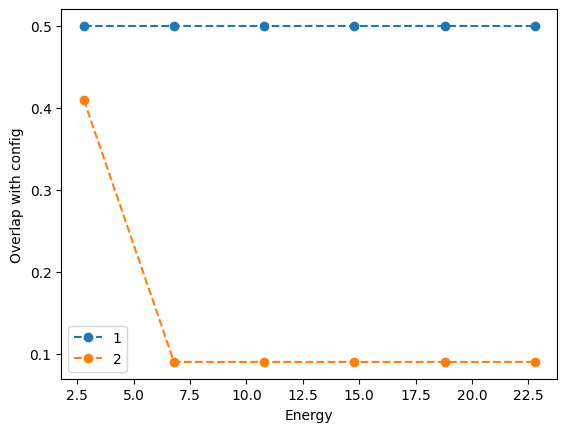

In [ ]:
for cutoff in range(1,L-7):
    print(cutoff)
    dat=[]
    for E0, config in zip(Es_sorted,configs_sorted):
        #print(E0,config[:1])
        
        psix = state_x(config,basis)
        overlap = np.vdot(psix,V0)**2
        P=array(mod_fin_string(config[:cutoff],"x")[0].todense())
        overlap = np.vdot(V0,P@V0)
        dat.append(overlap)
    dat = array(dat)

    plot(Es_sorted,dat,"--o",label=cutoff)
xlabel("Energy")
ylabel("Overlap with config")
legend()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/627228059.py:13: RuntimeWarning: divide by zero encountered in matmul
  expts = [ np.vdot(V0,p@V0) for p in P]
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/627228059.py:13: RuntimeWarning: overflow encountered in matmul
  expts = [ np.vdot(V0,p@V0) for p in P]
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/627228059.py:13: RuntimeWarning: invalid value encountered in matmul
  expts = [ np.vdot(V0,p@V0) for p in P]


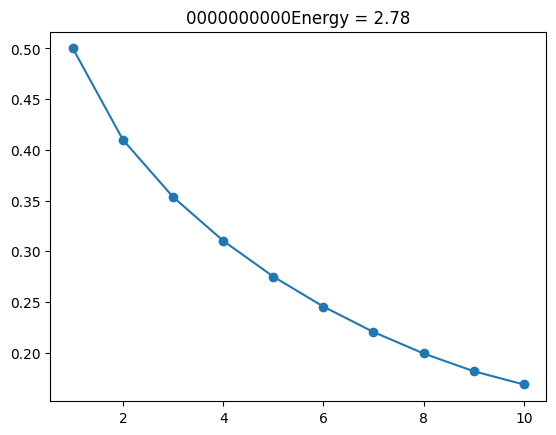

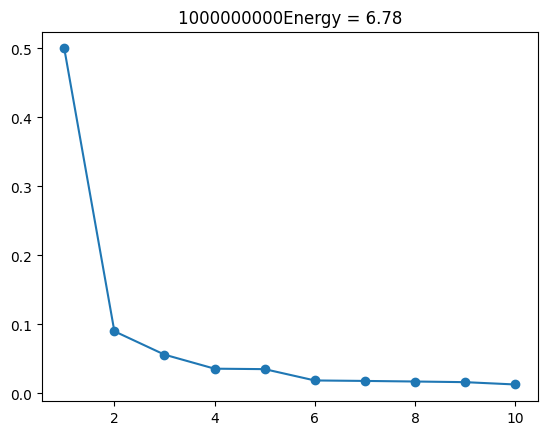

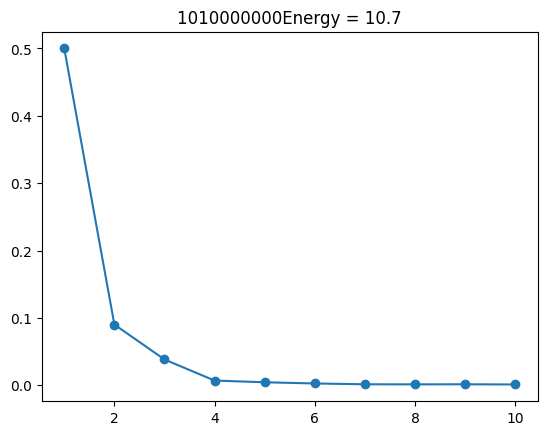

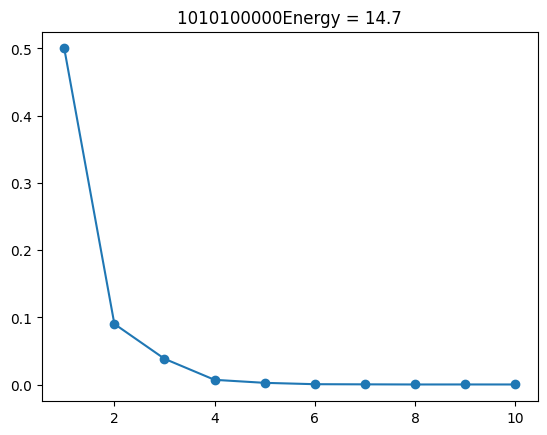

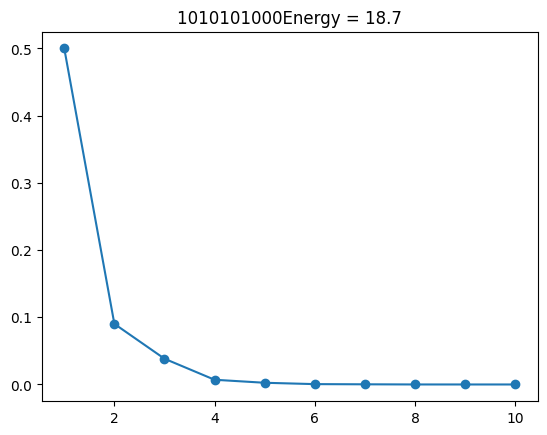

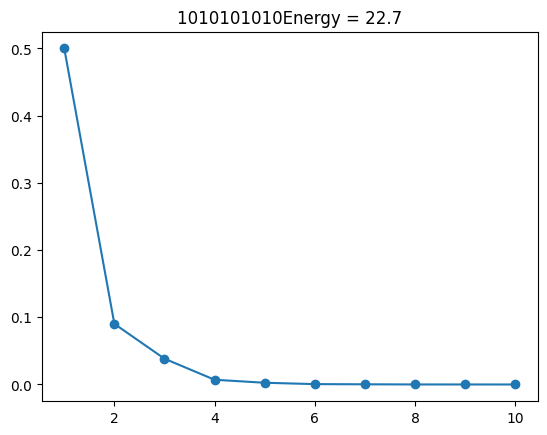

IndexError: list index out of range

In [ ]:
import random 
for i in range(9):
    j = i#random.randint(0,255)
    if i==0:
        j=0
    else:
        pass
    c= configs_sorted[j]

    plt.title(c+ " Energy = "+ str(Es_sorted[j])[1:5])
    
    P=[array(mod_fin_string(c[:k],"x")[0].todense()) for k in np.arange(1,len(c)+1)]
    expts = [ np.vdot(V0,p@V0) for p in P]
    plot(np.arange(1,len(c)+1),expts,"-o")
    show()


In [10]:
from joblib import Parallel, delayed
import numpy as np

def compute_expts(i):
    j = 0 if i == 0 else i
    c = configs_sorted[j]
    P = [np.array(mod_fin_string(c[:k], "x")[0].todense())
         for k in range(1, len(c)+1)]
    expts = [np.vdot(V0, p @ V0) for p in P]
    return j, c, expts

results = Parallel(n_jobs=-1)(
    delayed(compute_expts)(i) for i in range(0,256)
)

# plotting (serial)
for j, c, expts in results:
    plt.title(c + " Energy = " + str(Es_sorted[j])[1:5])
    plt.plot(np.arange(1, len(c)+1), expts, "-o")
    plt.show()


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/1491317534.py:9: RuntimeWarning: divide by zero encountered in matmul
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/1491317534.py:9: RuntimeWarning: overflow encountered in matmul
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/1491317534.py:9: RuntimeWarning: invalid value encountered in matmul
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/1491317534.py:9: RuntimeWarning: divide by zero encountered in matmul
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/1491317534.py:9: RuntimeWarning: overflow encountered in matmul
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/1491317534.py:9: RuntimeWarning: invalid value encountered in matmul
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/1491317534.py:9: RuntimeWarning: divide by zero encountered in matmul
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/1491

KeyboardInterrupt: 

/home/kristian/miniconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/kristian/miniconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


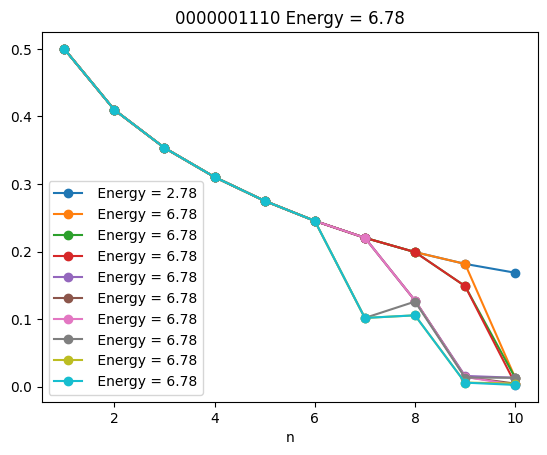

In [349]:

# plotting (serial)
for j, c, expts in results[:10]:
    plt.title(c + " Energy = " + str(Es_sorted[j])[1:5])
    plt.plot(np.arange(1, len(c)+1), expts, "-o",label=" Energy = " + str(Es_sorted[j])[1:5])
legend()
xlabel("n")
plt.show()

In [351]:
def thermal_expt(beta,V,E,op):
    Z=0
    expt=  0
    for i,Ei in enumerate(E):
        psi = V[:,i]
        weight = np.exp(-beta*Ei)
        Z+= weight
        expt+= np.vdot(psi, op @ psi)* weight
    return expt/Z

/tmp/ipykernel_15800/2300395875.py:6: RuntimeWarning: overflow encountered in exp
  weight = np.exp(-beta*Ei)
/tmp/ipykernel_15800/2300395875.py:8: RuntimeWarning: invalid value encountered in scalar multiply
  expt+= np.vdot(psi, op @ psi)* weight
/tmp/ipykernel_15800/2300395875.py:9: RuntimeWarning: invalid value encountered in scalar divide
  return expt/Z


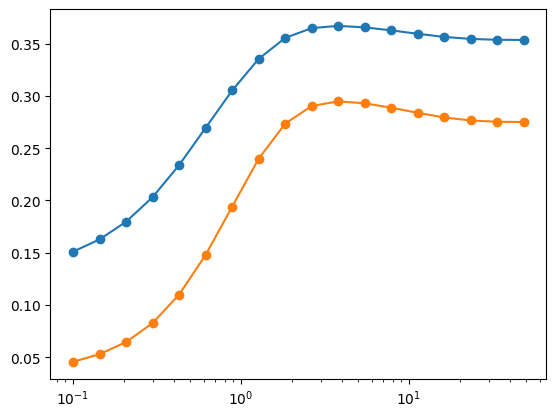

In [370]:
C0= configs_sorted[0]
P = [array(mod_fin_string(C0[:i],op)[0].todense()) for i in range(1,8)]
T= np.logspace(-1,2,20)
plot(T,[thermal_expt(i,V,E,P[2]) for i in T])
plot(T,[thermal_expt(i,V,E,P[4]) for i in T])
C0= configs_sorted[1]
P = [array(mod_fin_string(C0[:i],op)[0].todense()) for i in range(1,8)]
scatter(T,[thermal_expt(i,V,E,P[2]) for i in T])
scatter(T,[thermal_expt(i,V,E,P[4]) for i in T])
xscale("log")

/tmp/ipykernel_15800/2300395875.py:6: RuntimeWarning: overflow encountered in exp
  weight = np.exp(-beta*Ei)
/tmp/ipykernel_15800/2300395875.py:8: RuntimeWarning: invalid value encountered in scalar multiply
  expt+= np.vdot(psi, op @ psi)* weight
/tmp/ipykernel_15800/2300395875.py:9: RuntimeWarning: invalid value encountered in scalar divide
  return expt/Z


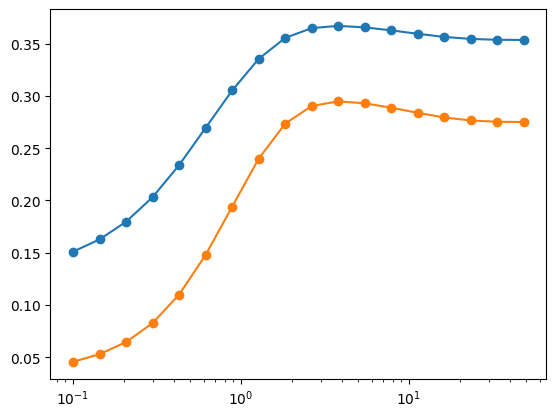

In [371]:
C0= configs_sorted[2]
P = [array(mod_fin_string(C0[:i],op)[0].todense()) for i in range(1,8)]
T= np.logspace(-1,2,20)
plot(T,[thermal_expt(i,V,E,P[2]) for i in T])
plot(T,[thermal_expt(i,V,E,P[4]) for i in T])
C0= configs_sorted[3]
P = [array(mod_fin_string(C0[:i],op)[0].todense()) for i in range(1,8)]
scatter(T,[thermal_expt(i,V,E,P[2]) for i in T])
scatter(T,[thermal_expt(i,V,E,P[4]) for i in T])
xscale("log")

/tmp/ipykernel_15800/2300395875.py:6: RuntimeWarning: overflow encountered in exp
  weight = np.exp(-beta*Ei)
/tmp/ipykernel_15800/2300395875.py:8: RuntimeWarning: invalid value encountered in scalar multiply
  expt+= np.vdot(psi, op @ psi)* weight
/tmp/ipykernel_15800/2300395875.py:9: RuntimeWarning: invalid value encountered in scalar divide
  return expt/Z


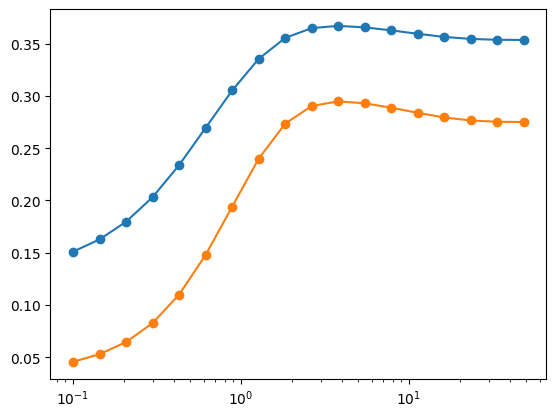

In [372]:
C0= configs_sorted[4]
P = [array(mod_fin_string(C0[:i],op)[0].todense()) for i in range(1,8)]
T= np.logspace(-1,2,20)
plot(T,[thermal_expt(i,V,E,P[2]) for i in T])
plot(T,[thermal_expt(i,V,E,P[4]) for i in T])
C0= configs_sorted[5]
P = [array(mod_fin_string(C0[:i],op)[0].todense()) for i in range(1,8)]
scatter(T,[thermal_expt(i,V,E,P[2]) for i in T])
scatter(T,[thermal_expt(i,V,E,P[4]) for i in T])
xscale("log")

/tmp/ipykernel_15800/2300395875.py:6: RuntimeWarning: overflow encountered in exp
  weight = np.exp(-beta*Ei)
/tmp/ipykernel_15800/2300395875.py:8: RuntimeWarning: invalid value encountered in scalar multiply
  expt+= np.vdot(psi, op @ psi)* weight
/tmp/ipykernel_15800/2300395875.py:9: RuntimeWarning: invalid value encountered in scalar divide
  return expt/Z
/home/kristian/miniconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/kristian/miniconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/kristian/miniconda3/lib/python3.12/site-packages/matplotlib/collections.py:197: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


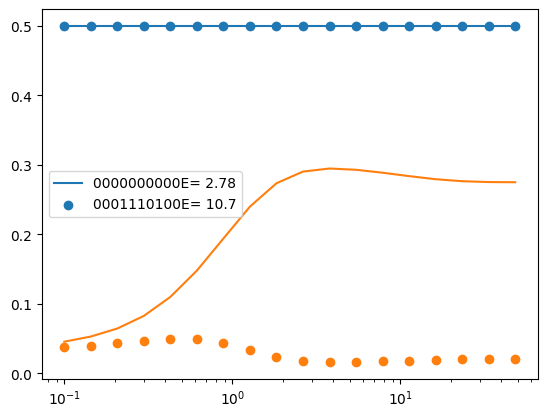

In [385]:
C0= configs_sorted[0]
C1= configs_sorted[100]

P = [array(mod_fin_string(C0[:i],op)[0].todense()) for i in [1,5]]
T= np.logspace(-1,2,20)
plot(T,[thermal_expt(i,V,E,P[0]) for i in T],label=C0+"E= "+str(Es_sorted[0])[1:5])
plot(T,[thermal_expt(i,V,E,P[1]) for i in T])
P = [array(mod_fin_string(C1[:i],op)[0].todense()) for i in [1,5]]
scatter(T,[thermal_expt(i,V,E,P[0]) for i in T],label=C1+"E= "+str(Es_sorted[100])[1:5])
scatter(T,[thermal_expt(i,V,E,P[1]) for i in T])
xscale("log")
legend()

/home/kristian/miniconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/kristian/miniconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


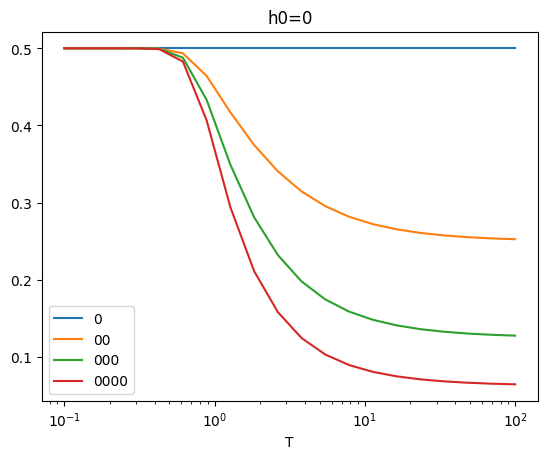

In [412]:
projs = ["0","00","000","0000"]
for p in projs:
    P = array(mod_fin_string(p,op)[0].todense())
    T= np.logspace(-1,2,20)
    plot(T,[thermal_expt(1/i,V,E,P) for i in T],label=p)
xscale("log")
plt.title(f"h0={h0}")
xlabel("T")
legend()

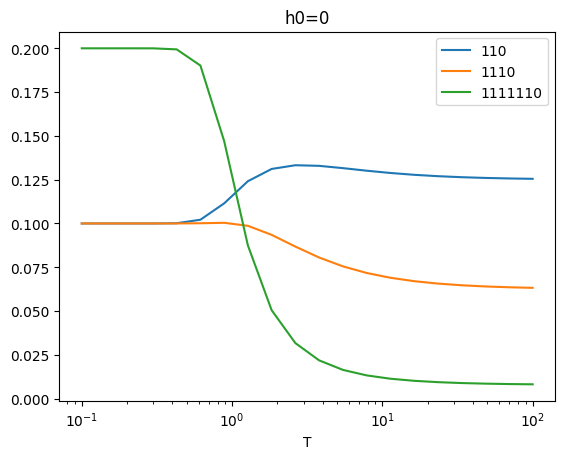

In [415]:
projs = ["110","1110","1111110"]
for p in projs:
    P = array(mod_fin_string(p,op)[0].todense())
    T= np.logspace(-1,2,20)
    plot(T,[thermal_expt(1/i,V,E,P) for i in T],label=p)
xscale("log")
plt.title(f"h0={h0}")
xlabel("T")
legend()

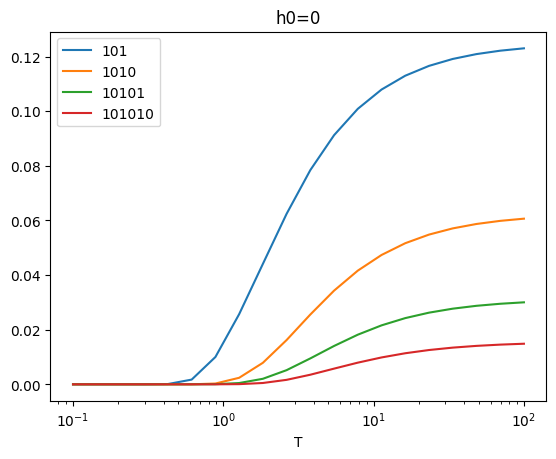

In [426]:
projs = ["101","1010","10101","101010"]
for p in projs:
    P = array(mod_fin_string(p,op)[0].todense())
    T= np.logspace(-1,2,20)
    plot(T,[thermal_expt(1/i,V,E,P) for i in T],label=p)
xscale("log")
plt.title(f"h0={h0}")
xlabel("T")
legend()

In [444]:
P = array(mod_fin_string("0",op)[0].todense())
np.linalg.eigh(P@H0@P)

EighResult(eigenvalues=array([-10.  ,  -4.86,  -4.86, ...,   2.16,   2.5 ,   2.5 ]), eigenvectors=array([[ 3.12500000e-02+0.j,  6.97795097e-11+0.j,  7.22016544e-22+0.j,
        ..., -1.56250000e-01+0.j,  4.41941738e-02+0.j,
         4.93471530e-16+0.j],
       [-3.12500000e-02+0.j, -2.14018841e-02+0.j,  2.23181031e-02+0.j,
        ...,  3.12500000e-02+0.j,  7.49400542e-16+0.j,
        -4.41941738e-02+0.j],
       [-3.12500000e-02+0.j, -1.28929746e-02+0.j, -3.03107266e-02+0.j,
        ...,  3.12500000e-02+0.j, -1.27815389e-15+0.j,
         4.41941738e-02+0.j],
       ...,
       [-3.12500000e-02+0.j,  1.28929746e-02+0.j,  3.03107266e-02+0.j,
        ...,  3.12500000e-02+0.j,  4.37150316e-16+0.j,
        -4.41941738e-02+0.j],
       [-3.12500000e-02+0.j,  2.14018841e-02+0.j, -2.23181031e-02+0.j,
        ...,  3.12500000e-02+0.j, -7.84962373e-16+0.j,
         4.41941738e-02+0.j],
       [ 3.12500000e-02+0.j, -6.97795491e-11+0.j,  1.05167611e-17+0.j,
        ..., -1.56250000e-01+0.j, -4.41

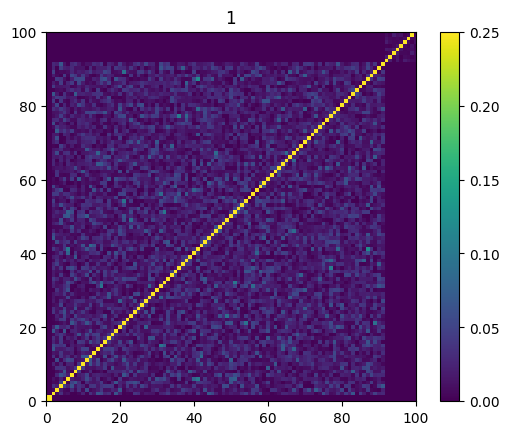

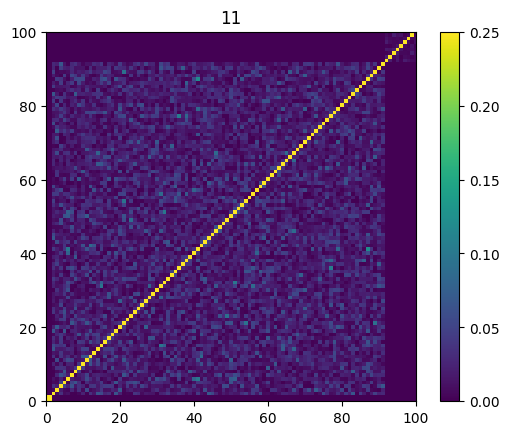

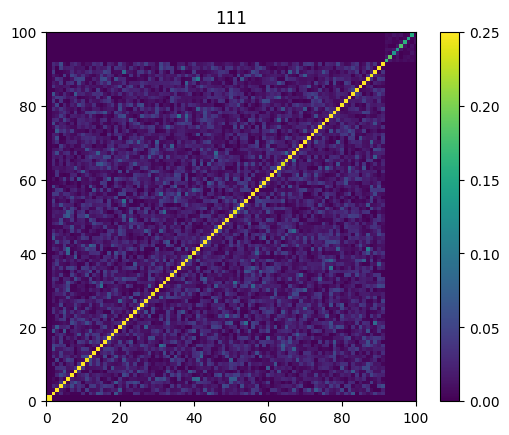

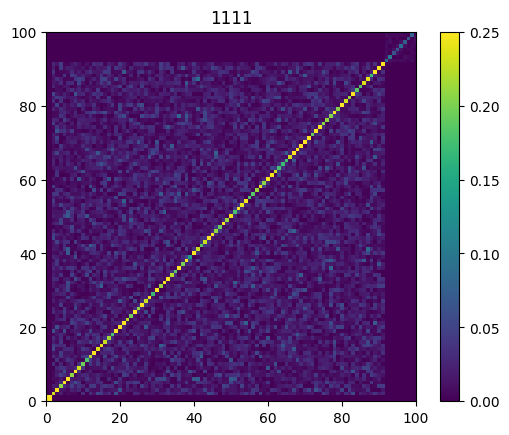

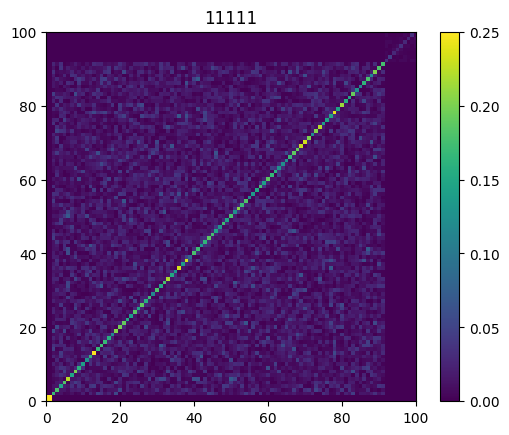

In [494]:
configs= ["1","11","111","1111",'11111']
for c in configs:
    P = array(mod_fin_string(c,op)[0].todense())

    plt.imshow(np.abs(V.T@P@V),vmin=0, vmax=.25)
    plt.title(c)
    plt.xlim(0,100)
    plt.ylim(0,100)
    plt.colorbar()
    show()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/707749301.py:5: RuntimeWarning: divide by zero encountered in matmul
  plt.imshow(np.abs(V.T@P@V),vmin=0, vmax=.5,extent=[E[0],E[-1],E[0],E[-1]])
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/707749301.py:5: RuntimeWarning: overflow encountered in matmul
  plt.imshow(np.abs(V.T@P@V),vmin=0, vmax=.5,extent=[E[0],E[-1],E[0],E[-1]])
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/707749301.py:5: RuntimeWarning: invalid value encountered in matmul
  plt.imshow(np.abs(V.T@P@V),vmin=0, vmax=.5,extent=[E[0],E[-1],E[0],E[-1]])


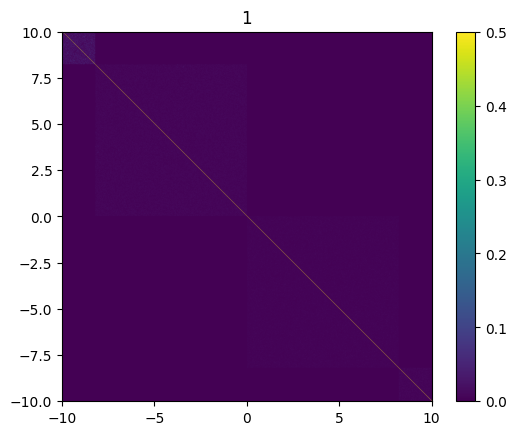

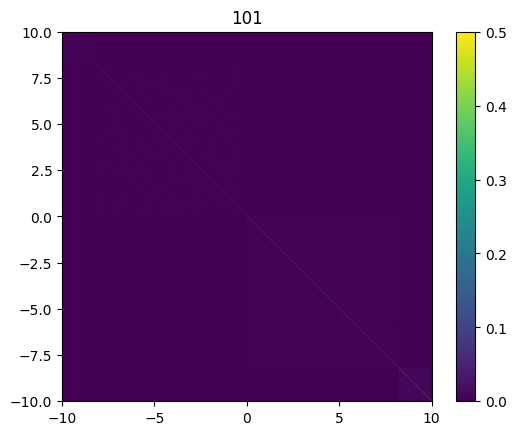

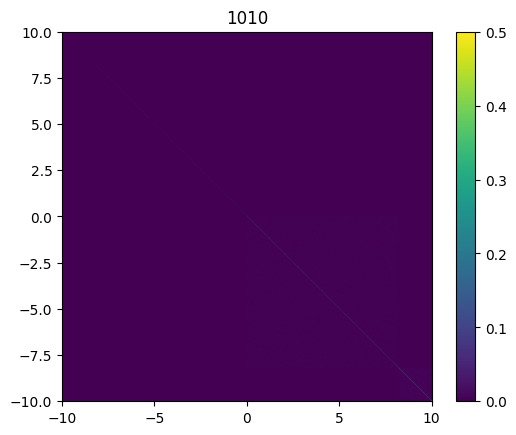

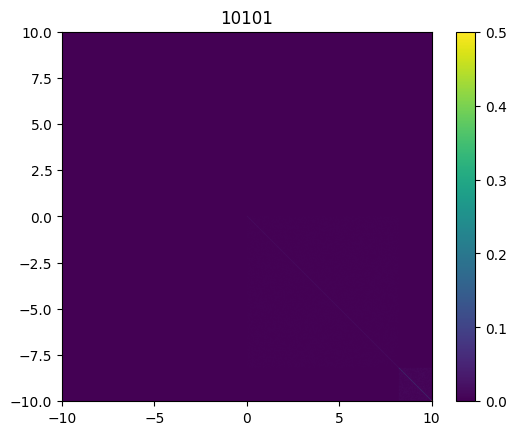

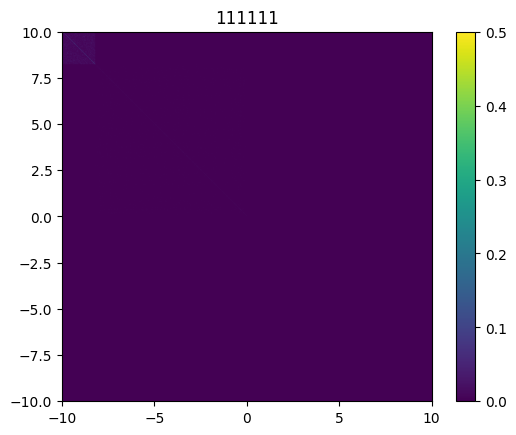

In [44]:
configs= ["1","101","1010","10101",'111111']
for c in configs:
    P = array(mod_fin_string(c,op)[0].todense())

    plt.imshow(np.abs(V.T@P@V),vmin=0, vmax=.5,extent=[E[0],E[-1],E[0],E[-1]])
    plt.title(c)
    #plt.xlim(00,100)
    #plt.ylim(00,100)
    plt.colorbar()
    show()
    

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/2351018330.py:6: RuntimeWarning: divide by zero encountered in matmul
  scatter(dE,np.abs(V.T@P@V).ravel(),label=c)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/2351018330.py:6: RuntimeWarning: overflow encountered in matmul
  scatter(dE,np.abs(V.T@P@V).ravel(),label=c)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/2351018330.py:6: RuntimeWarning: invalid value encountered in matmul
  scatter(dE,np.abs(V.T@P@V).ravel(),label=c)


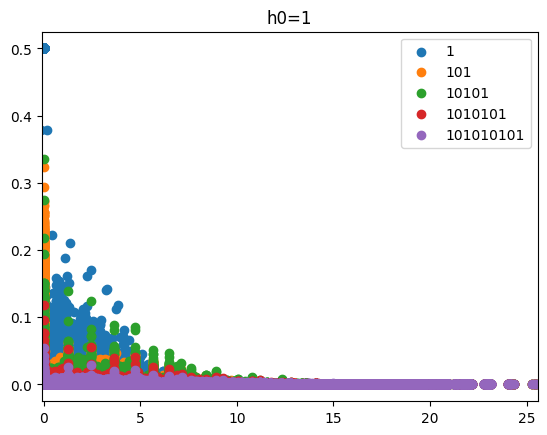

In [63]:
configs= ["1","101","10101","1010101","101010101"]
for c in configs:
    P = array(mod_fin_string(c,op)[0].todense())
    dE = E[:,None]-E[None,:]
    dE = dE.ravel()
    scatter(dE,np.abs(V.T@P@V).ravel(),label=c)
    plt.title(f"h0={h0}")
    plt.xlim(-0.1,max(dE))
    #plt.xlim(00,100)
    #plt.ylim(00,100)
    #plt.colorbar()
    #show()
legend()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/565007353.py:6: RuntimeWarning: divide by zero encountered in matmul
  scatter(dE,np.abs(V.T@P@V).ravel(),label=c)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/565007353.py:6: RuntimeWarning: overflow encountered in matmul
  scatter(dE,np.abs(V.T@P@V).ravel(),label=c)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/565007353.py:6: RuntimeWarning: invalid value encountered in matmul
  scatter(dE,np.abs(V.T@P@V).ravel(),label=c)


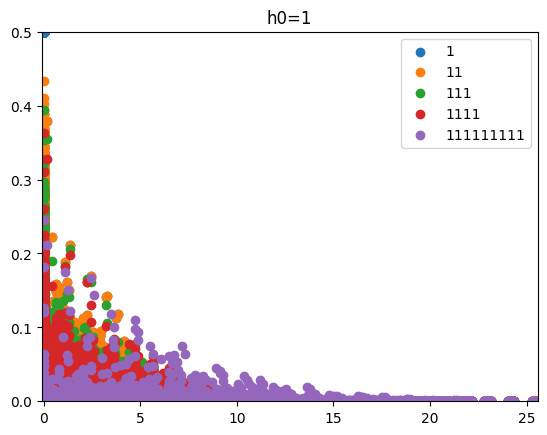

In [64]:
configs= ["1","11","111","1111","111111111"]
for c in configs:
    P = array(mod_fin_string(c,op)[0].todense())
    dE = E[:,None]-E[None,:]
    dE = dE.ravel()
    scatter(dE,np.abs(V.T@P@V).ravel(),label=c)
    plt.title(f"h0={h0}")
    plt.xlim(-0.1,max(dE))
    #plt.xlim(00,100)
    #plt.ylim(00,100)
    #plt.colorbar()
    #show()
plt.ylim(0,0.5)
legend()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/53825394.py:8: RuntimeWarning: divide by zero encountered in matmul
  scatter(dE,np.abs(V.T@P@V).ravel(),label=c)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/53825394.py:8: RuntimeWarning: overflow encountered in matmul
  scatter(dE,np.abs(V.T@P@V).ravel(),label=c)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/53825394.py:8: RuntimeWarning: invalid value encountered in matmul
  scatter(dE,np.abs(V.T@P@V).ravel(),label=c)


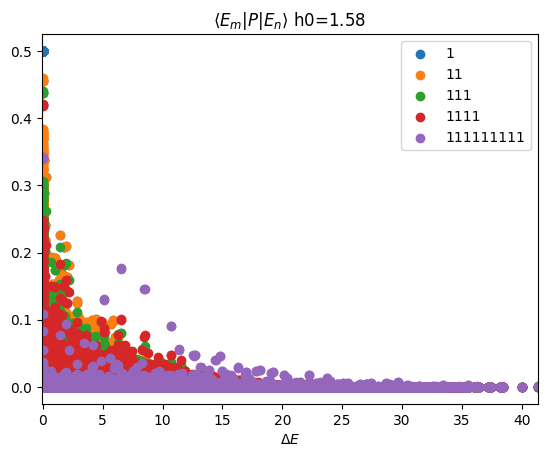

In [87]:
configs= ["1","01","0101","010101","01010101"]
configs= ["1","11","111","1111","111111111"]

for c in configs:
    P = array(mod_fin_string(c,op)[0].todense())
    dE = E[:,None]-E[None,:]
    dE = dE.ravel()
    scatter(dE,np.abs(V.T@P@V).ravel(),label=c)
    plt.title(rf"$\langle E_m | P |E_n \rangle$ h0={h0}")
    plt.xlim(-0.1,max(dE))
    #plt.xlim(00,100)
    #plt.ylim(00,100)
    #plt.colorbar()
    #show()
plt.xlabel(r"$\Delta E$")
legend()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/1954156027.py:8: RuntimeWarning: divide by zero encountered in matmul
  scatter(dE,np.abs(V.T@P@V).ravel(),label=c)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/1954156027.py:8: RuntimeWarning: overflow encountered in matmul
  scatter(dE,np.abs(V.T@P@V).ravel(),label=c)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/1954156027.py:8: RuntimeWarning: invalid value encountered in matmul
  scatter(dE,np.abs(V.T@P@V).ravel(),label=c)


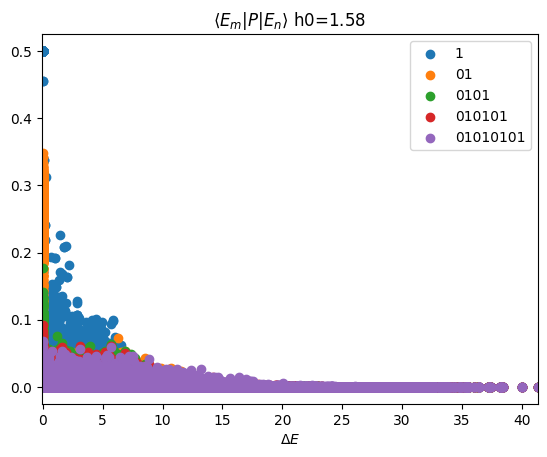

In [88]:
configs= ["1","01","0101","010101","01010101"]
#configs= ["1","11","111","1111","111111111"]

for c in configs:
    P = array(mod_fin_string(c,op)[0].todense())
    dE = E[:,None]-E[None,:]
    dE = dE.ravel()
    scatter(dE,np.abs(V.T@P@V).ravel(),label=c)
    plt.title(rf"$\langle E_m | P |E_n \rangle$ h0={h0}")
    plt.xlim(-0.1,max(dE))
    #plt.xlim(00,100)
    #plt.ylim(00,100)
    #plt.colorbar()
    #show()
plt.xlabel(r"$\Delta E$")
legend()

1


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/3086156451.py:9: RuntimeWarning: divide by zero encountered in matmul
  scatter(dE,np.abs(V.T@P@V).ravel(),label=c)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/3086156451.py:9: RuntimeWarning: overflow encountered in matmul
  scatter(dE,np.abs(V.T@P@V).ravel(),label=c)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45761/3086156451.py:9: RuntimeWarning: invalid value encountered in matmul
  scatter(dE,np.abs(V.T@P@V).ravel(),label=c)


01
011
0111
011111111


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


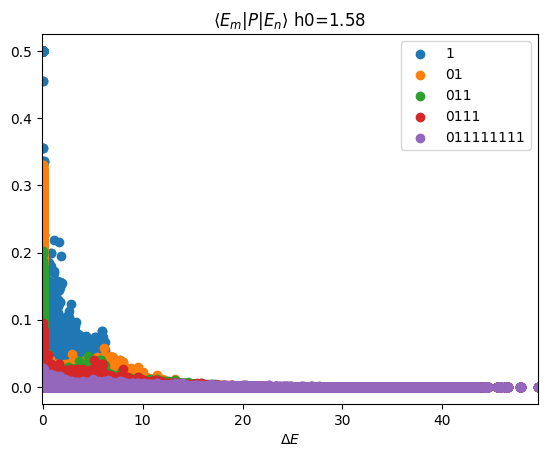

In [94]:
configs= ["1","01","0101","010101","01010101"]
configs= ["1","01","011","0111","011111111"]

for c in configs:
    print(c)
    P = array(mod_fin_string(c,op)[0].todense())
    dE = E[:,None]-E[None,:]
    dE = dE.ravel()
    scatter(dE,np.abs(V.T@P@V).ravel(),label=c)
    plt.title(rf"$\langle E_m | P |E_n \rangle$ h0={h0}")
    plt.xlim(-0.1,max(dE))
    #plt.xlim(00,100)
    #plt.ylim(00,100)
    #plt.colorbar()
    #show()
plt.xlabel(r"$\Delta E$")
legend()